In [1]:
import numpy as np
import matplotlib.pyplot as plt
import process_data as pd

In [2]:
QKE = pd.make_data_dictionary("../results/51-full_QKE.csv", "../results/51-full_QKE-eps.csv")

In [3]:
QKE.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w', 'dnde'])

In [4]:
V_QKE = pd.V_mat(QKE)

In [5]:
t = QKE['time']
Vy = V_QKE[1,:]
Vx = V_QKE[0,:]
Vz = V_QKE[2,:]
dy = np.diff(Vy)

In [6]:
#Create arrays for times where peaks occur and the peak values of each component of V

xlist = []
Vylist = []
Vxlist = []
Vzlist = []

for i in range(len(dy)-1):
    if dy[i]*dy[i+1]<0:
        coeff = np.polyfit(t[i:i+3],Vy[i:i+3],2)
        p = np.poly1d(coeff)
        x_max = -coeff[1]/(2*coeff[0])
        xlist.append(x_max)
        Vylist.append(p(x_max))

        coeff = np.polyfit(t[i:i+3], Vx[i:i+3],2)
        p=np.poly1d(coeff)
        x_max = -coeff[1]/(2*coeff[0])
        Vxlist.append(p(x_max))

        coeff = np.polyfit(t[i:i+3], Vz[i:i+3],2)
        p=np.poly1d(coeff)
        x_max = -coeff[1]/(2*coeff[0])
        Vzlist.append(p(x_max))

x_peaks = np.array(xlist)
Vy_peaks = np.array(Vylist)
Vx_peaks = np.array(Vxlist)
Vz_peaks = np.array(Vzlist)

24
8.981569425445217


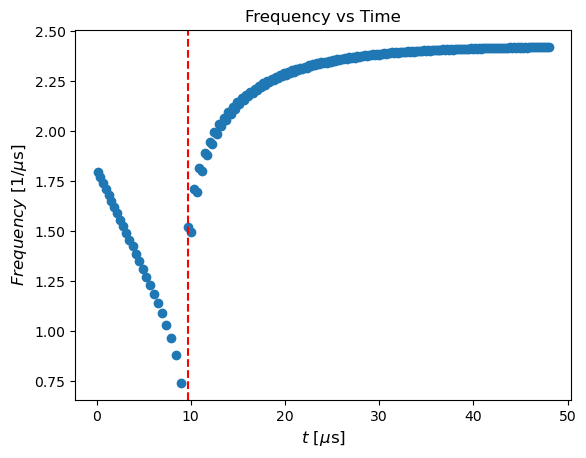

In [7]:
#Plot frequency vs time with vertical line where behavior changes

freq = 0.5 / np.diff(x_peaks)

jump = np.abs(np.diff(freq))
threshold = np.argmax(jump)
t_change_index = threshold
t_change = x_peaks[threshold]
print(t_change_index)
print(t_change)

plt.figure()
plt.scatter(x_peaks[:-1], freq)
plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
plt.ylabel(r"$Frequency~[1/\mu\text{s}]$", fontsize=12)
plt.title("Frequency vs Time")

plt.axvline(x=x_peaks[threshold + 1], color='r', linestyle='--', label='Behavior Changes')



Text(0.5, 1.0, 'Frequency vs Time (after 8.981569425445217 $\\mu\\text{s}$)')

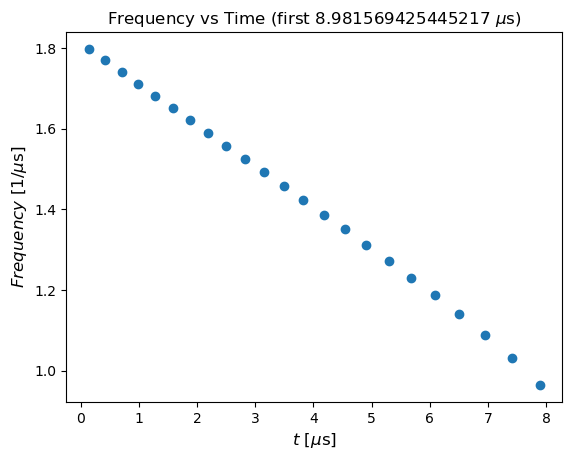

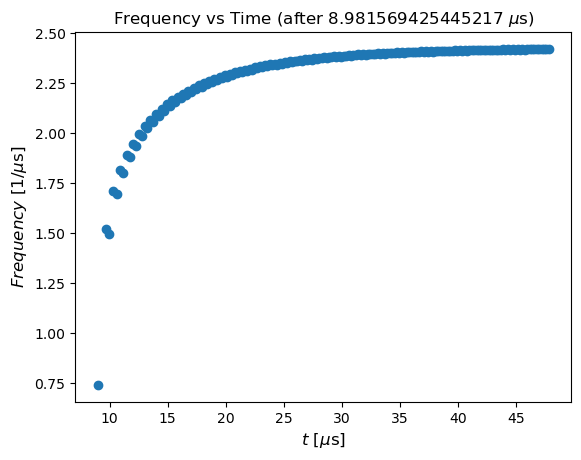

In [8]:
x_peaks_early = x_peaks[0:t_change_index]
x_peaks_late = x_peaks[t_change_index:-1]
plt.figure()
plt.scatter(x_peaks_early[:-1], 0.5/np.diff(x_peaks_early))
plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
plt.ylabel(r"$Frequency~[1/\mu\text{s}]$", fontsize=12)
plt.title(fr"Frequency vs Time (first {t_change} $\mu\text{{s}}$)")
plt.figure()
plt.scatter(x_peaks_late[:-1], 0.5/np.diff(x_peaks_late))
plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
plt.ylabel(r"$Frequency~[1/\mu\text{s}]$", fontsize=12)
plt.title(fr"Frequency vs Time (after {t_change} $\mu\text{{s}}$)")

Text(0.5, 1.0, 'peak values of V vs time (all times)')

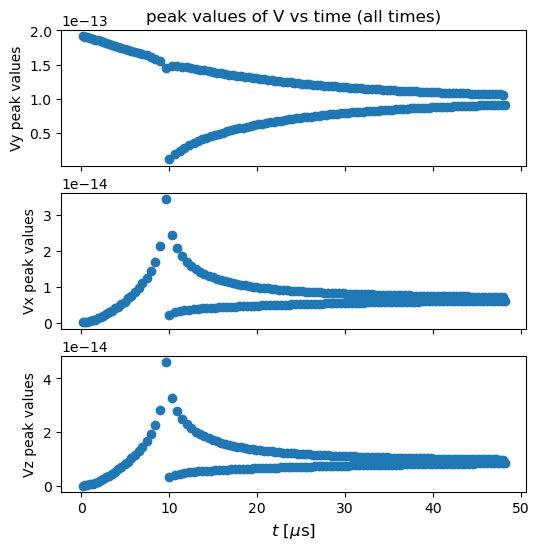

In [9]:
#peak values of V vs time all times

fig, ax = plt.subplots(figsize=(6,6), nrows=3, ncols=1, sharex=True)


ax[0].scatter(x_peaks,np.abs(Vy_peaks))
ax[0].set_ylabel("Vy peak values")

ax[1].scatter(x_peaks,np.abs(Vx_peaks))
ax[1].set_ylabel("Vx peak values")

ax[2].scatter(x_peaks,np.abs(Vz_peaks))
ax[2].set_ylabel("Vz peak values")


ax[2].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
ax[0].set_title("peak values of V vs time (all times)")

Text(0.5, 1.0, 'Peak Values of V vs Time (first 8.981569425445217 $\\mu\\text{s}$)')

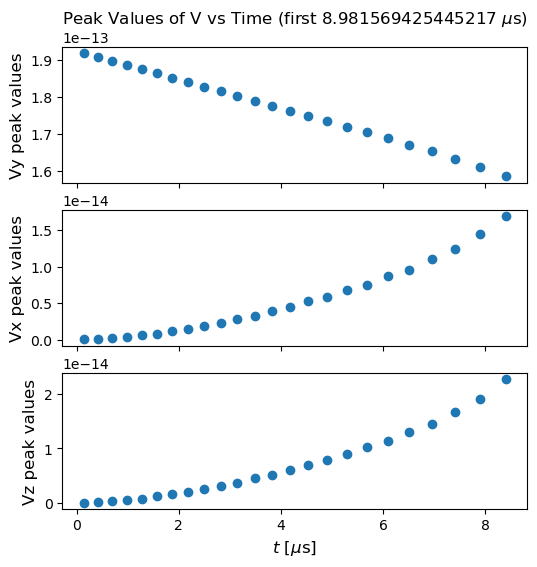

In [10]:
#peak values of V vs time (first ~9 sec)

fig, ax = plt.subplots(figsize=(6,6), nrows=3, ncols=1, sharex=True)


ax[0].scatter(x_peaks_early,np.abs(Vy_peaks[0:t_change_index]))
ax[0].set_ylabel("Vy peak values",fontsize=12)

ax[1].scatter(x_peaks_early,np.abs(Vx_peaks[0:t_change_index]))
ax[1].set_ylabel("Vx peak values",fontsize=12)

ax[2].scatter(x_peaks_early,np.abs(Vz_peaks[0:t_change_index]))
ax[2].set_ylabel("Vz peak values", fontsize=12)


ax[2].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
ax[0].set_title(fr"Peak Values of V vs Time (first {t_change} $\mu\text{{s}}$)")

Text(0.5, 1.0, 'Peak Values of V vs Time (after 8.981569425445217 $\\mu\\text{s}$)')

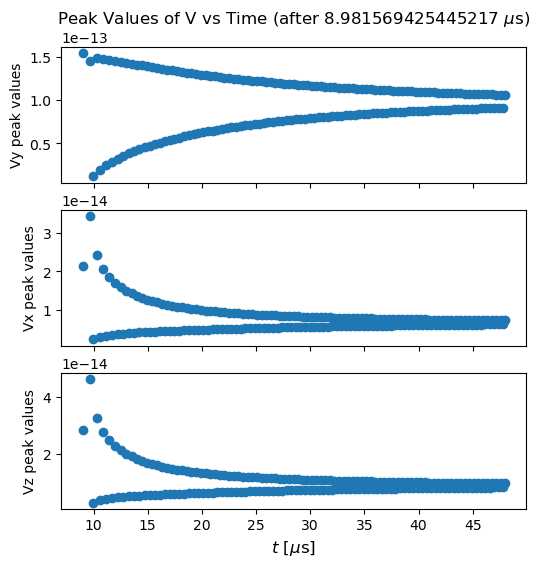

In [11]:
#peak values of V vs time (after 9 seconds)

fig, ax = plt.subplots(figsize=(6,6), nrows=3, ncols=1, sharex=True)


ax[0].scatter(x_peaks_late,np.abs(Vy_peaks[t_change_index:-1]))
ax[0].set_ylabel("Vy peak values")

ax[1].scatter(x_peaks_late,np.abs(Vx_peaks[t_change_index:-1]))
ax[1].set_ylabel("Vx peak values")

ax[2].scatter(x_peaks_late,np.abs(Vz_peaks[t_change_index:-1]))
ax[2].set_ylabel("Vz peak values")


ax[2].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
ax[0].set_title(fr"Peak Values of V vs Time (after {t_change} $\mu\text{{s}}$)")

Text(0.5, 1.0, 'Vy vs Vz')

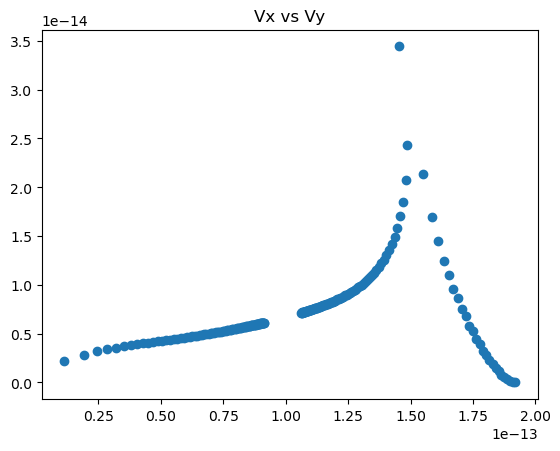

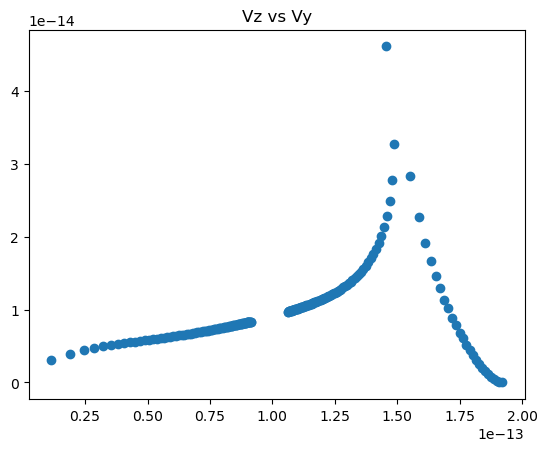

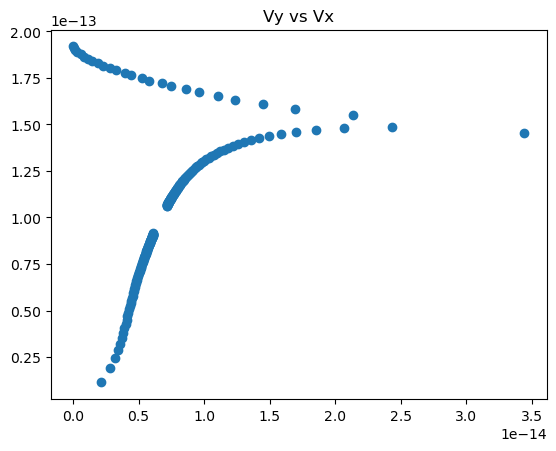

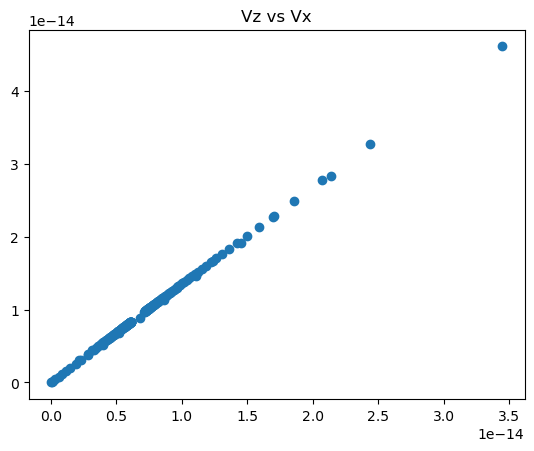

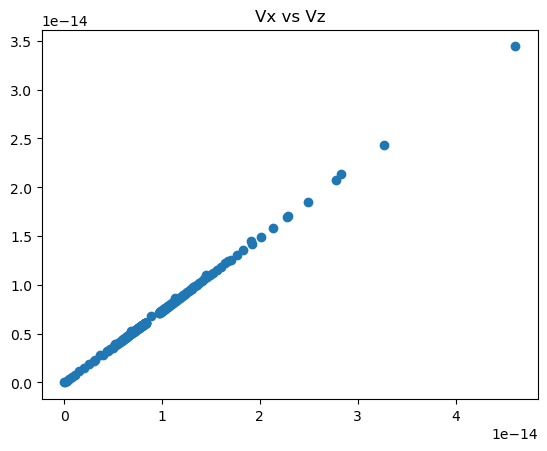

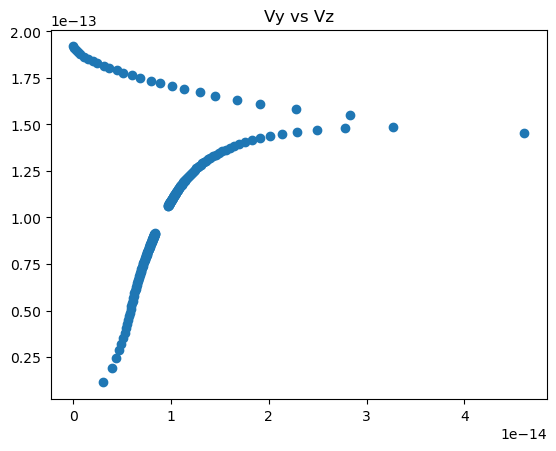

In [12]:
# all times
plt.figure()
plt.scatter(np.abs(Vy_peaks),np.abs(Vx_peaks))
plt.title("Vx vs Vy")

plt.figure()
plt.scatter(np.abs(Vy_peaks),np.abs(Vz_peaks))
plt.title("Vz vs Vy")

plt.figure()
plt.scatter(np.abs(Vx_peaks),np.abs(Vy_peaks))
plt.title("Vy vs Vx")

plt.figure()
plt.scatter(np.abs(Vx_peaks),np.abs(Vz_peaks))
plt.title("Vz vs Vx")

plt.figure()
plt.scatter(np.abs(Vz_peaks),np.abs(Vx_peaks))
plt.title("Vx vs Vz")

plt.figure()
plt.scatter(np.abs(Vz_peaks),np.abs(Vy_peaks))
plt.title("Vy vs Vz")

Text(0.5, 1.0, 'Vy vs Vz (first 8.981569425445217 $\\mu\\text{s}$)')

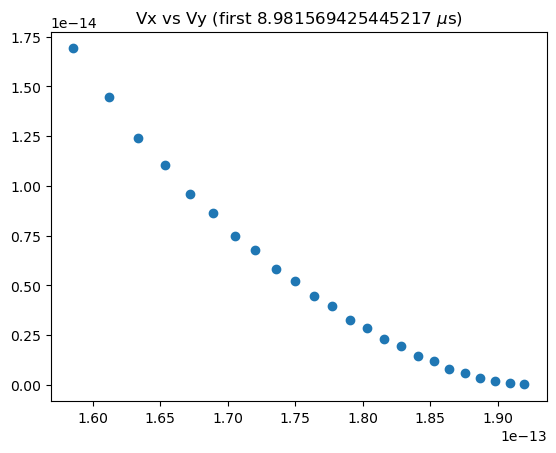

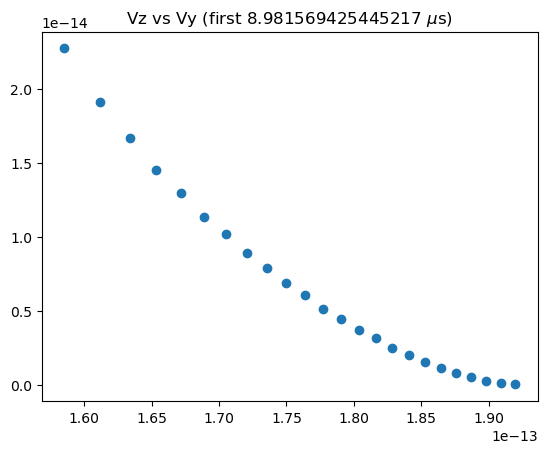

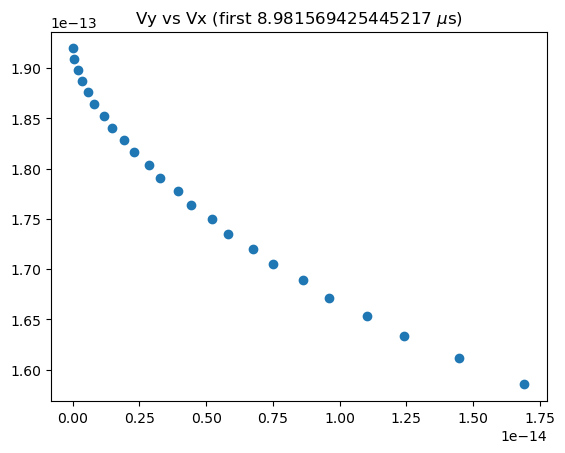

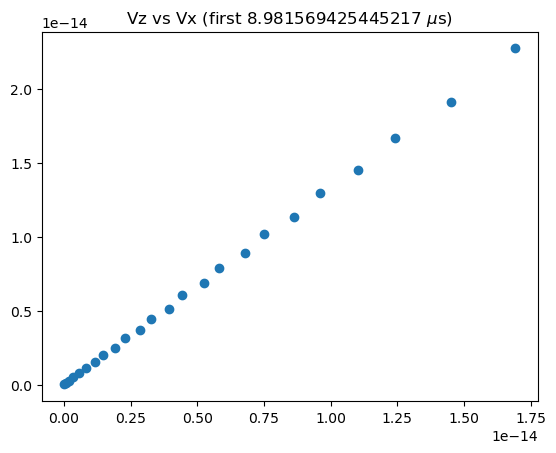

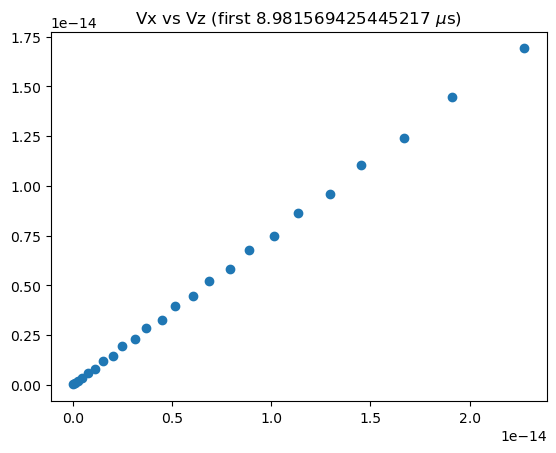

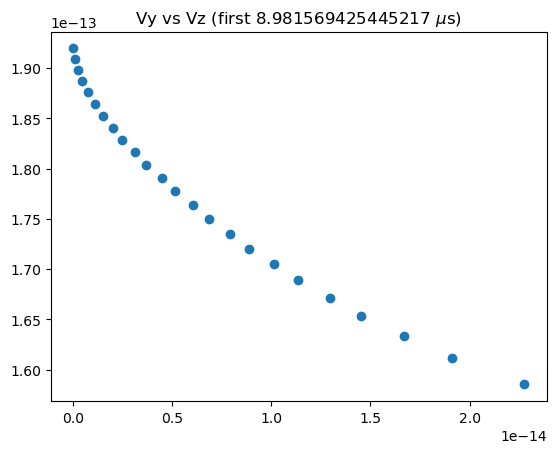

In [13]:
# first ~9 sec
plt.figure()
plt.scatter(np.abs(Vy_peaks[0:t_change_index]),np.abs(Vx_peaks[0:t_change_index]))
plt.title(fr"Vx vs Vy (first {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vy_peaks[0:t_change_index]),np.abs(Vz_peaks[0:t_change_index]))
plt.title(fr"Vz vs Vy (first {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vx_peaks[0:t_change_index]),np.abs(Vy_peaks[0:t_change_index]))
plt.title(fr"Vy vs Vx (first {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vx_peaks[0:t_change_index]),np.abs(Vz_peaks[0:t_change_index]))
plt.title(fr"Vz vs Vx (first {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vz_peaks[0:t_change_index]),np.abs(Vx_peaks[0:t_change_index]))
plt.title(fr"Vx vs Vz (first {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vz_peaks[0:t_change_index]),np.abs(Vy_peaks[0:t_change_index]))
plt.title(fr"Vy vs Vz (first {t_change} $\mu\text{{s}}$)")

Text(0.5, 1.0, 'Vy vs Vz (after 8.981569425445217 $\\mu\\text{s}$)')

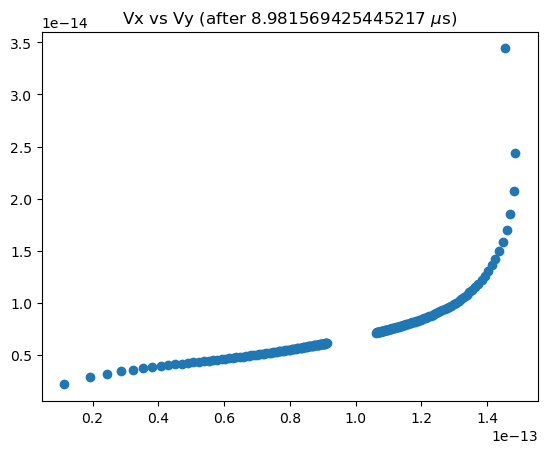

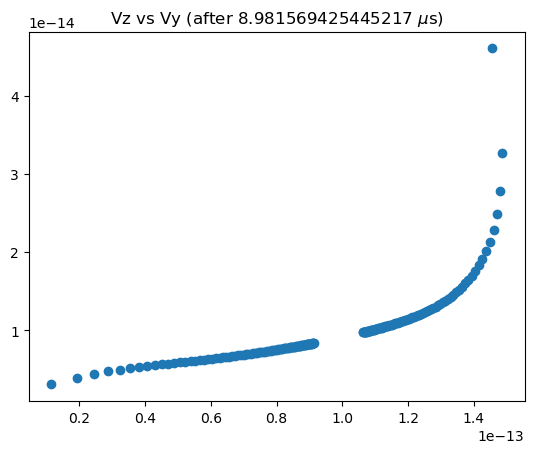

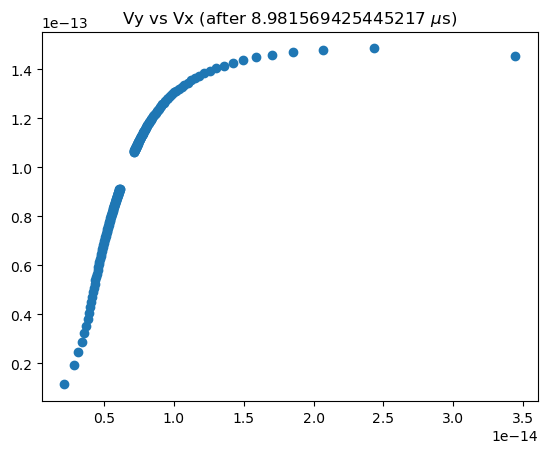

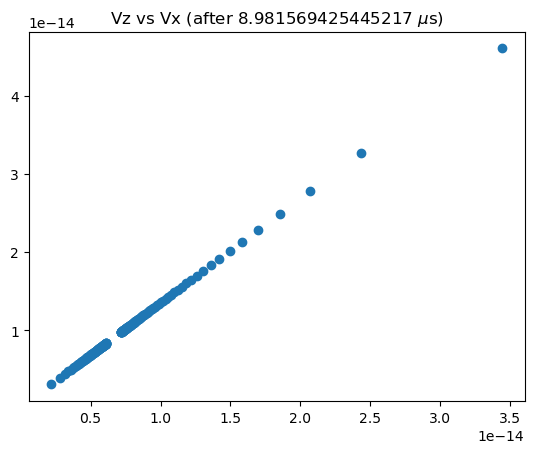

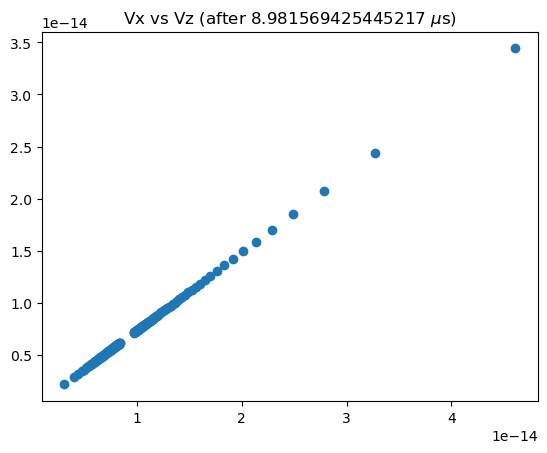

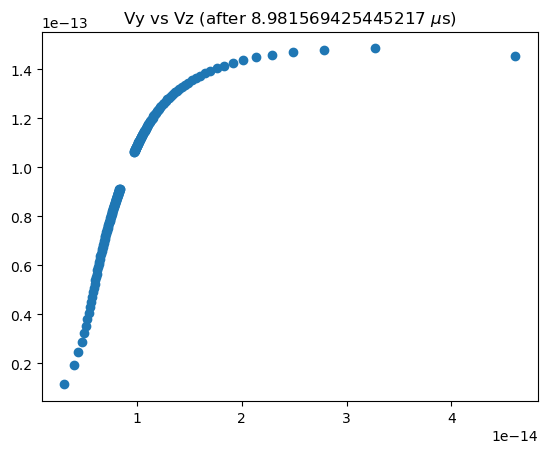

In [14]:
# after 9 sec
plt.figure()
plt.scatter(np.abs(Vy_peaks[25:-1]),np.abs(Vx_peaks[25:-1]))
plt.title(fr"Vx vs Vy (after {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vy_peaks[25:-1]),np.abs(Vz_peaks[25:-1]))
plt.title(fr"Vz vs Vy (after {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vx_peaks[25:-1]),np.abs(Vy_peaks[25:-1]))
plt.title(fr"Vy vs Vx (after {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vx_peaks[25:-1]),np.abs(Vz_peaks[25:-1]))
plt.title(fr"Vz vs Vx (after {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vz_peaks[25:-1]),np.abs(Vx_peaks[25:-1]))
plt.title(fr"Vx vs Vz (after {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vz_peaks[25:-1]),np.abs(Vy_peaks[25:-1]))
plt.title(fr"Vy vs Vz (after {t_change} $\mu\text{{s}}$)")

Text(0.5, 1.0, 'frequency vs Vz peak values (all times)')

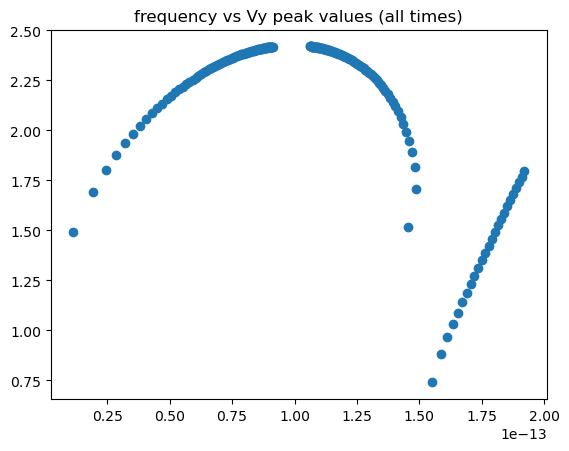

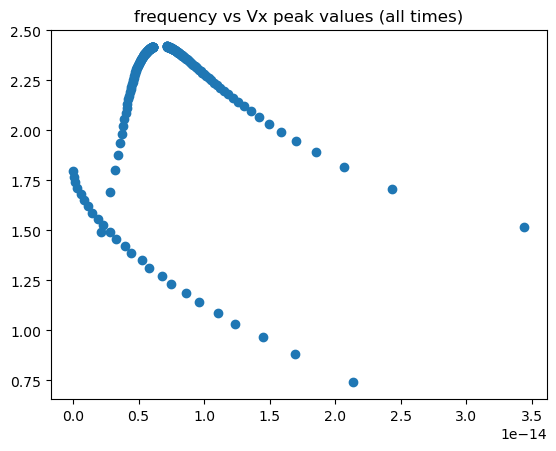

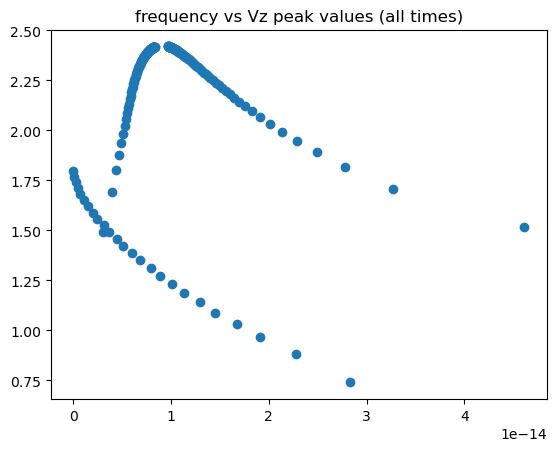

In [15]:
plt.figure()
plt.scatter(np.abs(Vy_peaks[:-1]), 0.5/np.diff(x_peaks))
plt.title("frequency vs Vy peak values (all times)")

plt.figure()
plt.scatter(np.abs(Vx_peaks[:-1]), 0.5/np.diff(x_peaks))
plt.title("frequency vs Vx peak values (all times)")

plt.figure()
plt.scatter(np.abs(Vz_peaks[:-1]), 0.5/np.diff(x_peaks))
plt.title("frequency vs Vz peak values (all times)")


Text(0.5, 1.0, 'Frequency vs Vz Peak Values (first 8.981569425445217 $\\mu\\text{s}$)')

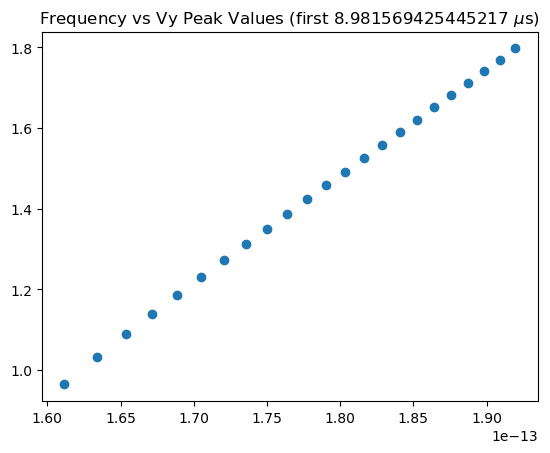

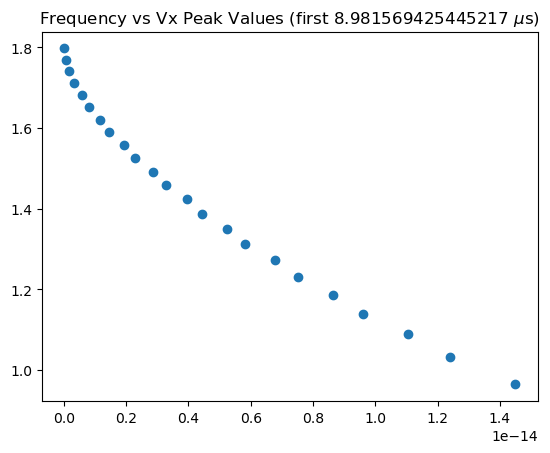

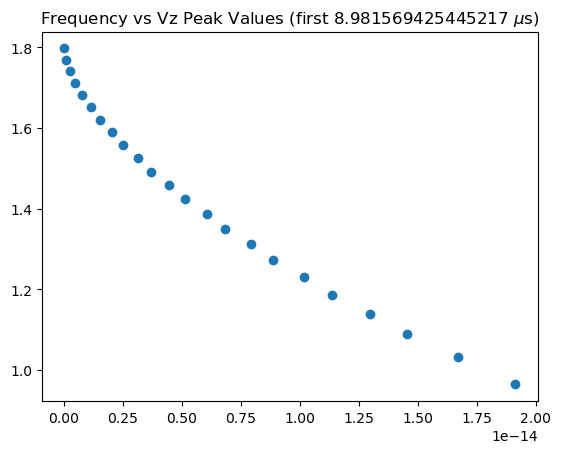

In [16]:
plt.figure()
plt.scatter(np.abs(Vy_peaks[0:t_change_index-1]), 0.5/np.diff(x_peaks_early))
plt.title(fr"Frequency vs Vy Peak Values (first {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vx_peaks[0:t_change_index-1]), 0.5/np.diff(x_peaks_early))
plt.title(fr"Frequency vs Vx Peak Values (first {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vz_peaks[0:t_change_index-1]), 0.5/np.diff(x_peaks_early))
plt.title(fr"Frequency vs Vz Peak Values (first {t_change} $\mu\text{{s}}$)")


Text(0.5, 1.0, 'Frequency vs Vz Peak Values (after 8.981569425445217 $\\mu\\text{s}$)')

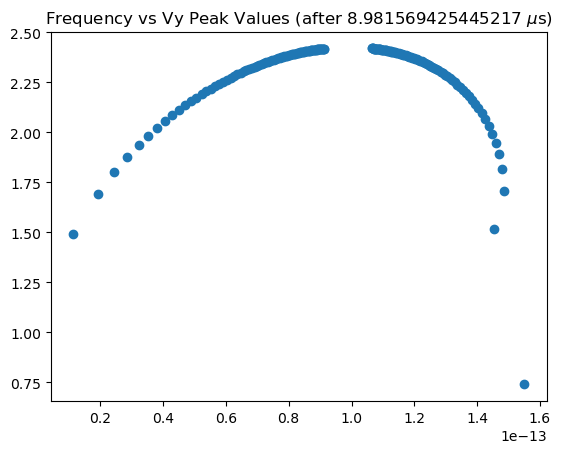

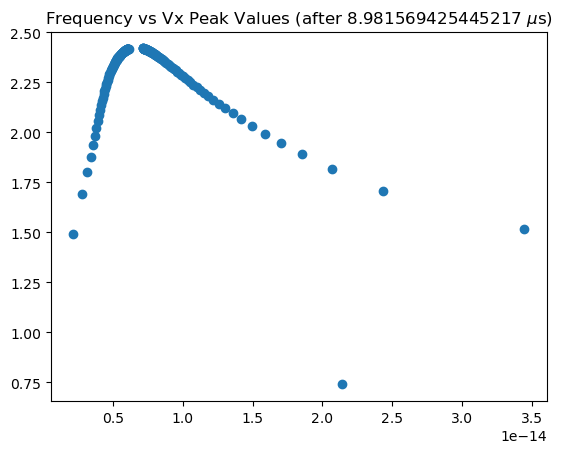

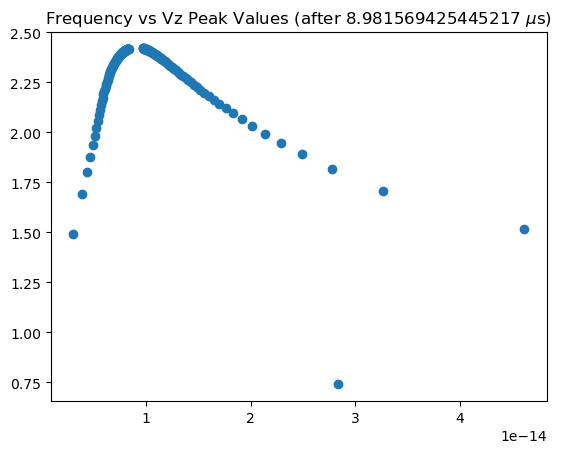

In [17]:
plt.figure()
plt.scatter(np.abs(Vy_peaks[t_change_index:-2]), 0.5/np.diff(x_peaks_late))
plt.title(fr"Frequency vs Vy Peak Values (after {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vx_peaks[t_change_index:-2]), 0.5/np.diff(x_peaks_late))
plt.title(fr"Frequency vs Vx Peak Values (after {t_change} $\mu\text{{s}}$)")

plt.figure()
plt.scatter(np.abs(Vz_peaks[t_change_index:-2]), 0.5/np.diff(x_peaks_late))
plt.title(fr"Frequency vs Vz Peak Values (after {t_change} $\mu\text{{s}}$)")


In [18]:
print(Vy_peaks[t_change_index:-2].shape)
print(np.diff(x_peaks_late).shape)

(177,)
(177,)


Text(0.5, 1.0, 'frequency vs |V| peak values (all times)')

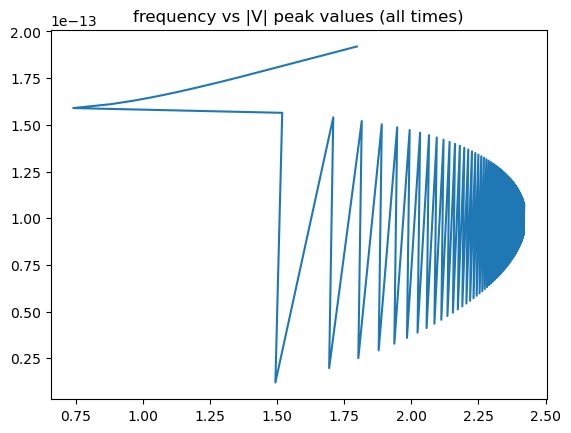

In [19]:
#frequency vs |V|
V = np.sqrt((Vx_peaks[:-1])**2+(Vy_peaks[:-1])**2+(Vz_peaks[:-1])**2)
plt.figure()
plt.plot(0.5/np.diff(x_peaks), V)
plt.title("frequency vs |V| peak values (all times)")

Text(0.5, 1.0, 'Frequency vs |V| Peak Values (first 8.981569425445217 $\\mu\\text{s}$)')

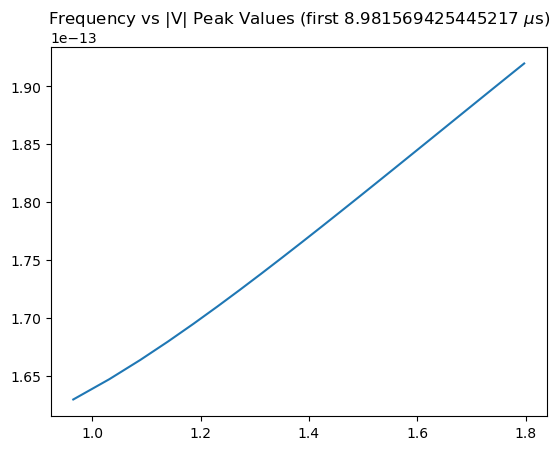

In [20]:
V = np.sqrt((Vx_peaks[:-1])**2+(Vy_peaks[:-1])**2+(Vz_peaks[:-1])**2)
plt.figure()
plt.plot(0.5/np.diff(x_peaks_early), V[0:t_change_index-1])
plt.title(fr"Frequency vs |V| Peak Values (first {t_change} $\mu\text{{s}}$)")

Text(0.5, 1.0, 'Frequency vs |V| Peak Values (after 8.981569425445217 $\\mu\\text{s}$)')

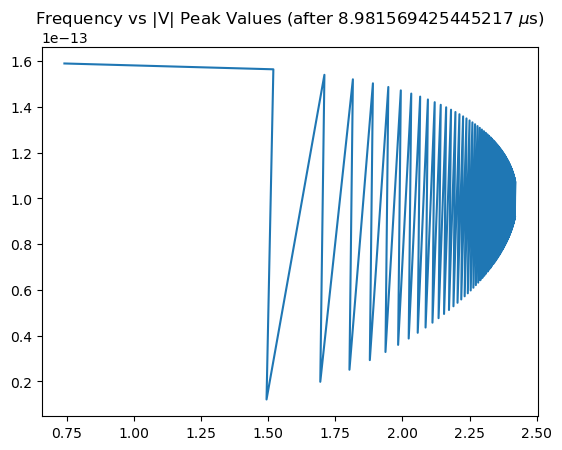

In [21]:
V = np.sqrt((Vx_peaks[:-1])**2+(Vy_peaks[:-1])**2+(Vz_peaks[:-1])**2)
plt.figure()
plt.plot(0.5/np.diff(x_peaks_late), V[t_change_index:-1])
plt.title(fr"Frequency vs |V| Peak Values (after {t_change} $\mu\text{{s}}$)")